In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from ucimlrepo import fetch_ucirepo 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (BaggingClassifier, AdaBoostClassifier, 
                              GradientBoostingClassifier, StackingClassifier, RandomForestClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.metrics import make_scorer, f1_score

In [3]:
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
df = pd.concat([X, y], axis=1)

In [4]:
print("Class Distribution (0: Benign, 1: Malignant):")
print(df['Diagnosis'].value_counts())

Class Distribution (0: Benign, 1: Malignant):
Diagnosis
B    357
M    212
Name: count, dtype: int64


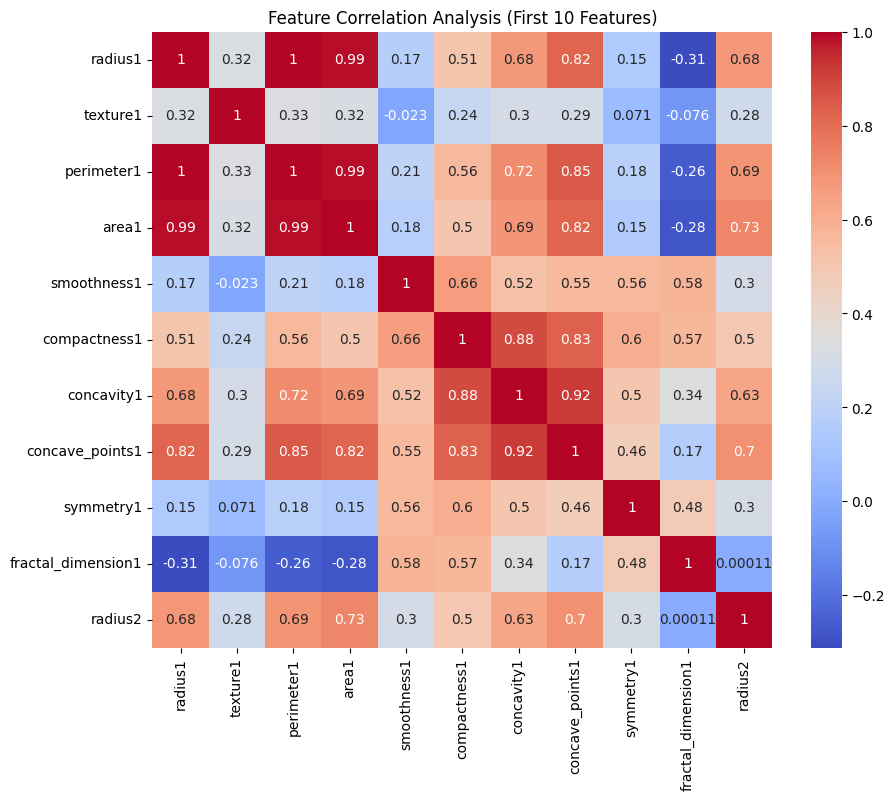

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.iloc[:, :11].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Analysis (First 10 Features)")
plt.show()

Class Distribution:
 Diagnosis
B            357
M            212
Name: count, dtype: int64


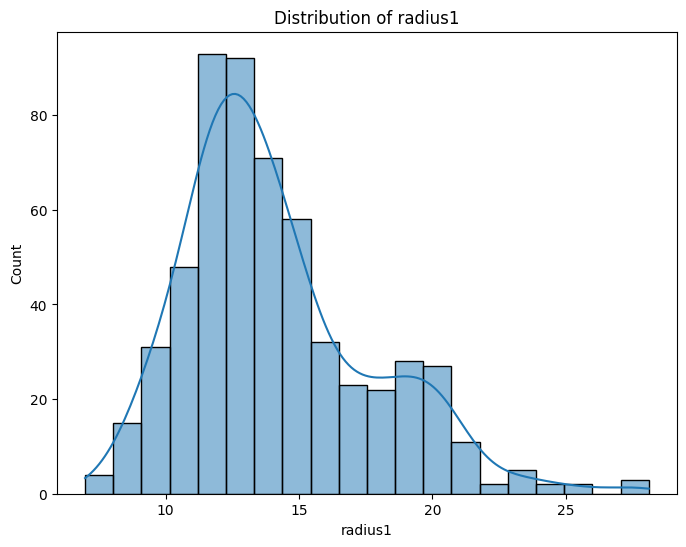

In [6]:
# 1. Print class distribution
print("Class Distribution:\n", y.value_counts())

# 2. Dynamically grab the name of the first column so we don't get a KeyError
first_column_name = X.columns[0]

# 3. Plot it
plt.figure(figsize=(8, 6))
sns.histplot(X[first_column_name], bins=20, kde=True)
plt.title(f'Distribution of {first_column_name}')
plt.show()

# Optional: If you want to see all the actual column names in your dataset, uncomment the line below:
# print(X.columns)

In [7]:
le = LabelEncoder()
y_encoded = le.fit_transform(y.values.ravel())

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.20, random_state=42)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
bag_params = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.8, 1.0]
}

bagging_grid = GridSearchCV(
    BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5), random_state=42), 
    bag_params, 
    cv=5, 
    scoring=['accuracy', 'f1'],  
    refit='accuracy'
)

bagging_grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",BaggingClassi...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_samples': [0.5, 0.8, ...], 'n_estimators': [10, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'f1']"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the s

In [11]:

ada_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}


ada_grid = GridSearchCV(
    AdaBoostClassifier(random_state=42), 
    ada_params, 
    cv=5, 
    scoring=['accuracy', 'f1'],  
    refit='accuracy'
)


ada_grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'f1']"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : t

In [12]:
base_learners = [
    ('bagging', bagging_grid.best_estimator_),
    ('adaboost', ada_grid.best_estimator_),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
]
stacking_clf = StackingClassifier(estimators=base_learners, final_estimator=LogisticRegression(), cv=5)
stacking_clf.fit(X_train_scaled, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('bagging', ...), ('adaboost', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum numb

In [13]:
cv_bag = cross_validate(bagging_grid.best_estimator_, X_train_scaled, y_train, cv=5)['test_score']
cv_ada = cross_validate(ada_grid.best_estimator_, X_train_scaled, y_train, cv=5)['test_score']
cv_stack = cross_validate(stacking_clf, X_train_scaled, y_train, cv=5)['test_score']

cv_comparison = pd.DataFrame([
    {'Model': 'Bagging', 'Fold 1': cv_bag[0], 'Fold 2': cv_bag[1], 'Fold 3': cv_bag[2], 'Fold 4': cv_bag[3], 'Fold 5': cv_bag[4], 'Average CV': np.mean(cv_bag)},
    {'Model': 'AdaBoost', 'Fold 1': cv_ada[0], 'Fold 2': cv_ada[1], 'Fold 3': cv_ada[2], 'Fold 4': cv_ada[3], 'Fold 5': cv_ada[4], 'Average CV': np.mean(cv_ada)},
    {'Model': 'Stacking', 'Fold 1': cv_stack[0], 'Fold 2': cv_stack[1], 'Fold 3': cv_stack[2], 'Fold 4': cv_stack[3], 'Fold 5': cv_stack[4], 'Average CV': np.mean(cv_stack)}
])
print("\n--- 5-Fold Cross-Validation Accuracy Comparison ---")
print(cv_comparison.to_string(index=False))


--- 5-Fold Cross-Validation Accuracy Comparison ---
   Model   Fold 1   Fold 2   Fold 3   Fold 4   Fold 5  Average CV
 Bagging 0.934066 0.967033 0.945055 0.967033 0.934066    0.949451
AdaBoost 0.978022 0.978022 1.000000 0.978022 0.967033    0.980220
Stacking 0.945055 0.945055 0.978022 0.967033 0.934066    0.953846


In [14]:
from sklearn.model_selection import cross_validate
import pandas as pd
import numpy as np

# 1. We just use the standard scoring list now! No custom scorer needed.
scoring_metrics = ['accuracy', 'f1']

# 2. Run 5-Fold Cross-Validation 
cv_stack_results = cross_validate(stacking_clf, X_train_scaled, y_train, cv=5, scoring=scoring_metrics)

# 3. Calculate the averages and convert them to clean percentages
avg_acc = np.mean(cv_stack_results['test_accuracy']) * 100
avg_f1 = np.mean(cv_stack_results['test_f1']) * 100

# 4. Build Table 3 EXACTLY with the columns requested by your lab manual
table3_df = pd.DataFrame({
    'Base Models': ['Bagging (DT), AdaBoost, Gradient Boosting'],
    'Meta-Learner': ['Logistic Regression'],
    'Avg CV Accuracy (%)': [round(avg_acc, 2)],
    'Avg CV F1 Score': [round(avg_f1, 2)]
})

print("\nTable 3: Stacked Ensemble Evaluation")
print("-" * 85)
print(table3_df.to_string(index=False))


Table 3: Stacked Ensemble Evaluation
-------------------------------------------------------------------------------------
                              Base Models        Meta-Learner  Avg CV Accuracy (%)  Avg CV F1 Score
Bagging (DT), AdaBoost, Gradient Boosting Logistic Regression                95.38            93.63



================ Bagging (Tuned) Evaluation ================
Accuracy:  0.9561
Precision: 0.9524
Recall:    0.9302
F1-Score:  0.9412
Confusion Matrix:
[[69  2]
 [ 3 40]]

================ AdaBoost (Tuned) Evaluation ================
Accuracy:  0.9649
Precision: 0.9756
Recall:    0.9302
F1-Score:  0.9524
Confusion Matrix:
[[70  1]
 [ 3 40]]

================ Stacked Ensemble Evaluation ================
Accuracy:  0.9561
Precision: 0.9524
Recall:    0.9302
F1-Score:  0.9412
Confusion Matrix:
[[69  2]
 [ 3 40]]


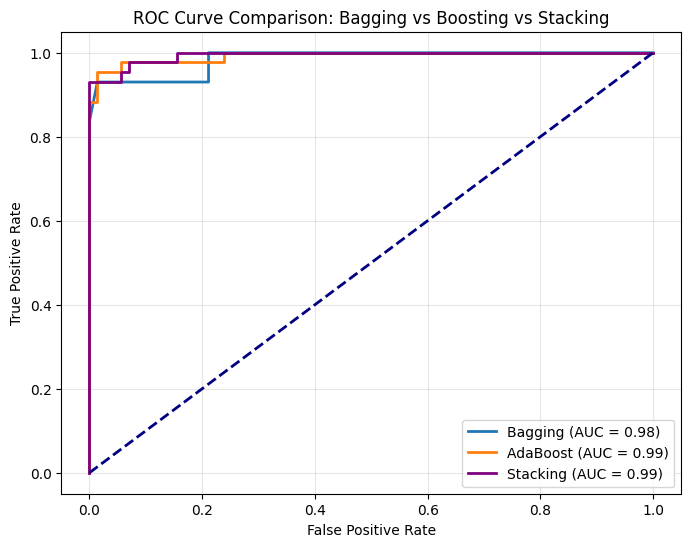

In [15]:
# --- CLEANED EVALUATION FUNCTION ---
def evaluate_and_plot(model, name, X_t, y_t):
    y_pred = model.predict(X_t)
    y_prob = model.predict_proba(X_t)[:, 1] 
    
    print(f"\n================ {name} Evaluation ================")
    print(f"Accuracy:  {accuracy_score(y_t, y_pred):.4f}")
    
    # Removed pos_label='M' since labels are now 0 and 1!
    print(f"Precision: {precision_score(y_t, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_t, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_t, y_pred):.4f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_t, y_pred)}")
    
    # Removed pos_label='M' here too!
    fpr, tpr, _ = roc_curve(y_t, y_prob)
    return fpr, tpr, auc(fpr, tpr)

# Evaluate all three
fpr_bag, tpr_bag, auc_bag = evaluate_and_plot(bagging_grid.best_estimator_, "Bagging (Tuned)", X_test_scaled, y_test)
fpr_ada, tpr_ada, auc_ada = evaluate_and_plot(ada_grid.best_estimator_, "AdaBoost (Tuned)", X_test_scaled, y_test)
fpr_stack, tpr_stack, auc_stack = evaluate_and_plot(stacking_clf, "Stacked Ensemble", X_test_scaled, y_test)

# Plot ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_bag, tpr_bag, lw=2, label=f'Bagging (AUC = {auc_bag:.2f})')
plt.plot(fpr_ada, tpr_ada, lw=2, label=f'AdaBoost (AUC = {auc_ada:.2f})')
plt.plot(fpr_stack, tpr_stack, lw=2, color='purple', label=f'Stacking (AUC = {auc_stack:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Bagging vs Boosting vs Stacking')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [16]:
print("\nTable 1: Bagging Hyperparameter Evaluation (Top Results)")
bag_results = pd.DataFrame(bagging_grid.cv_results_)

# Extract relevant columns
bag_table = bag_results[['param_n_estimators', 'param_max_samples', 'mean_test_accuracy', 'mean_test_f1']].copy()
bag_table = bag_table.sort_values(by='mean_test_accuracy', ascending=False).head(5)

# Rename and format
bag_table.columns = ['n_estimators', 'Max Samples', 'Avg CV Accuracy (%)', 'Avg CV F1 Score']
bag_table['Avg CV Accuracy (%)'] = (bag_table['Avg CV Accuracy (%)'] * 100).round(2)
bag_table['Avg CV F1 Score'] = (bag_table['Avg CV F1 Score'] * 100).round(2)

print(bag_table.to_string(index=False))


# =====================================================================
# --- TABLE 2: AdaBoost Hyperparameter Evaluation ---
# =====================================================================
print("\nTable 2: AdaBoost Hyperparameter Evaluation (Top Results)")
ada_results = pd.DataFrame(ada_grid.cv_results_)

# Extract relevant columns
ada_table = ada_results[['param_n_estimators', 'param_learning_rate', 'mean_test_accuracy', 'mean_test_f1']].copy()
ada_table = ada_table.sort_values(by='mean_test_accuracy', ascending=False).head(5)

# Rename and format
ada_table.columns = ['n_estimators', 'Learning Rate', 'Avg CV Accuracy (%)', 'Avg CV F1 Score']
ada_table['Avg CV Accuracy (%)'] = (ada_table['Avg CV Accuracy (%)'] * 100).round(2)
ada_table['Avg CV F1 Score'] = (ada_table['Avg CV F1 Score'] * 100).round(2)

print(ada_table.to_string(index=False))


Table 1: Bagging Hyperparameter Evaluation (Top Results)
 n_estimators  Max Samples  Avg CV Accuracy (%)  Avg CV F1 Score
           10          1.0                94.95            92.95
           50          0.5                94.73            92.80
           10          0.5                94.51            92.42
           50          0.8                94.51            92.46
          100          0.5                94.51            92.46

Table 2: AdaBoost Hyperparameter Evaluation (Top Results)
 n_estimators  Learning Rate  Avg CV Accuracy (%)  Avg CV F1 Score
           50            1.0                98.02            97.28
          200            1.0                97.80            96.90
          100            1.0                97.58            96.66
          200            0.1                96.92            95.73
          100            0.1                96.48            95.19


In [17]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# =====================================================================
# --- TABLE 4: Performance Comparison on Test Data ---
# =====================================================================
# List of our finalized models
models = [
    ('Bagging (Tuned)', bagging_grid.best_estimator_),
    ('AdaBoost (Tuned)', ada_grid.best_estimator_),
    ('Stacked Ensemble', stacking_clf)
]

table4_data = []

# Calculate metrics for each model on the TEST set
for name, model in models:
    y_pred = model.predict(X_test_scaled)
    table4_data.append({
        'Model': name,
        'Accuracy (%)': round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision (%)': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall (%)': round(recall_score(y_test, y_pred) * 100, 2),
        'F1-Score (%)': round(f1_score(y_test, y_pred) * 100, 2)
    })

table4_df = pd.DataFrame(table4_data)

print("\nTable 4: Performance Comparison on Test Data")
print("-" * 80)
print(table4_df.to_string(index=False))


Table 4: Performance Comparison on Test Data
--------------------------------------------------------------------------------
           Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
 Bagging (Tuned)         95.61          95.24       93.02         94.12
AdaBoost (Tuned)         96.49          97.56       93.02         95.24
Stacked Ensemble         95.61          95.24       93.02         94.12
